<a href="https://colab.research.google.com/github/Shiva160305/2520090092_ML/blob/main/Experiment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4           

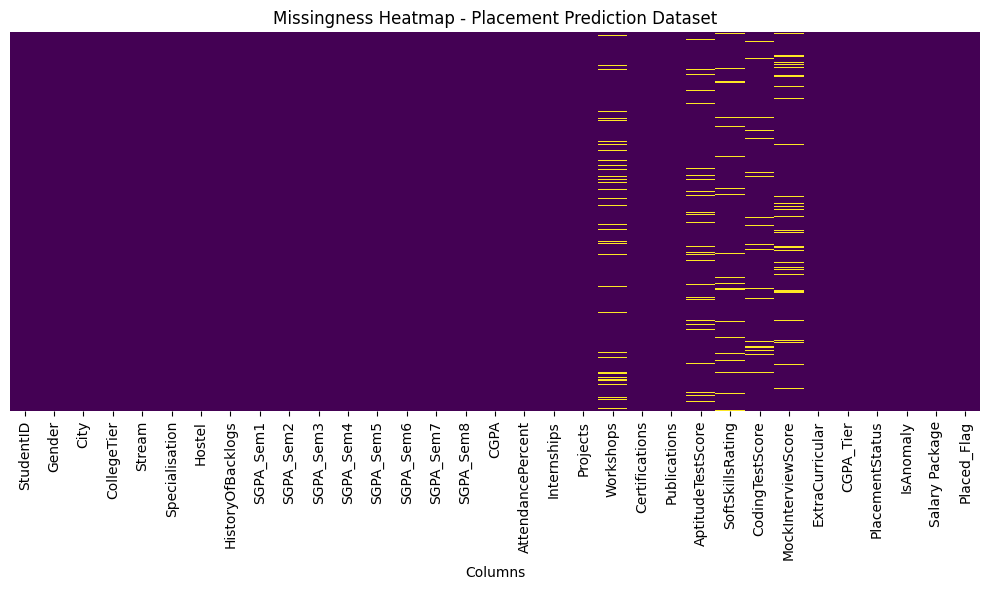

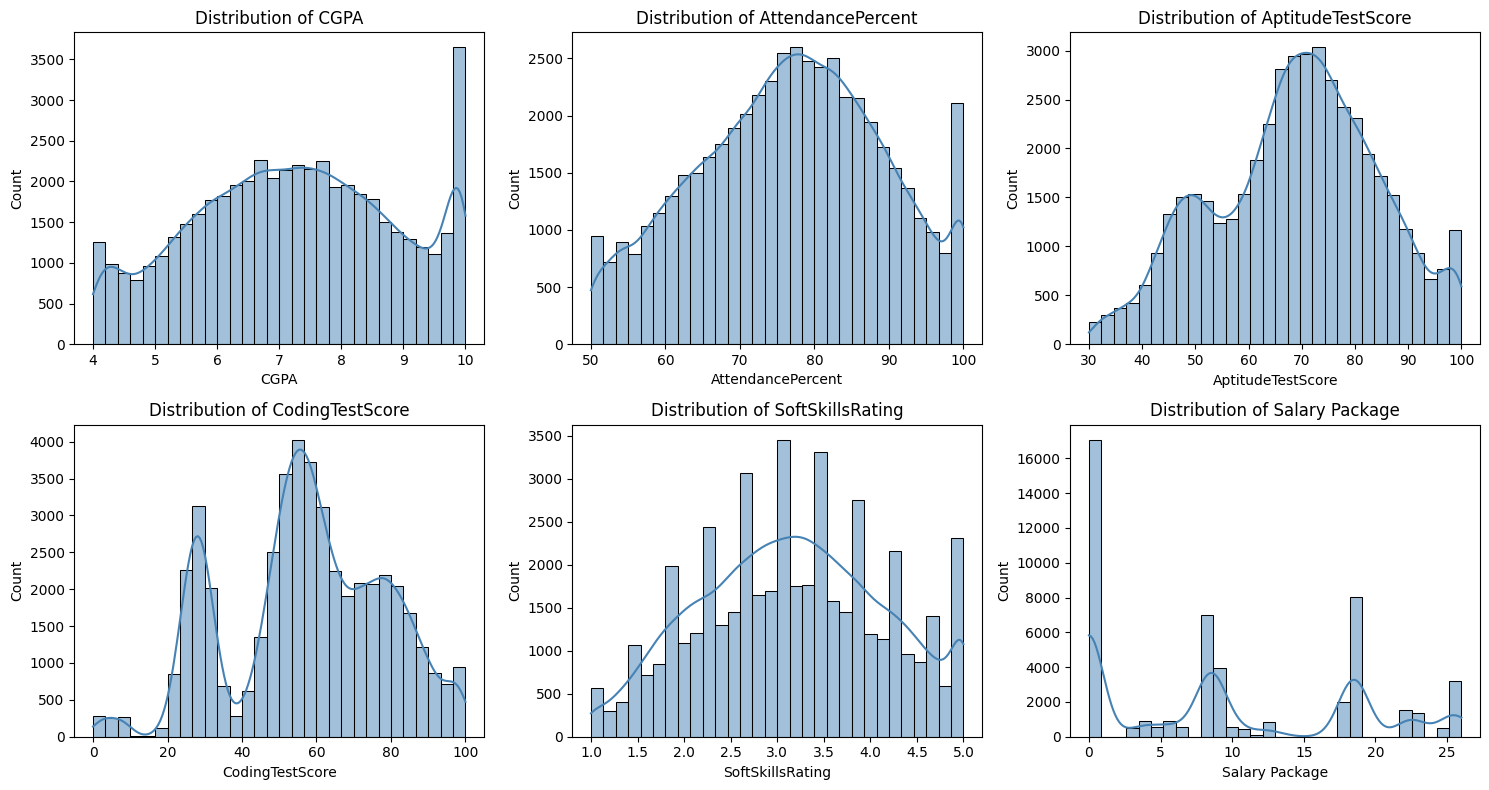

/tmp/ipykernel_1785/533271957.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')


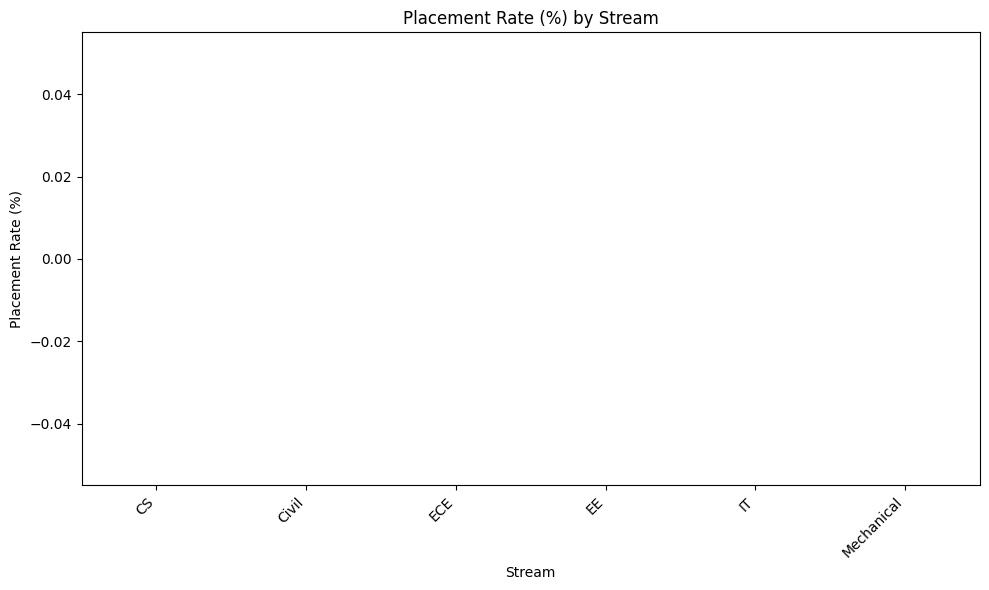


Placement rate (%) by stream:
Stream
CS            0.0
Civil         0.0
ECE           0.0
EE            0.0
IT            0.0
Mechanical    0.0
Name: Placed_Flag, dtype: float64


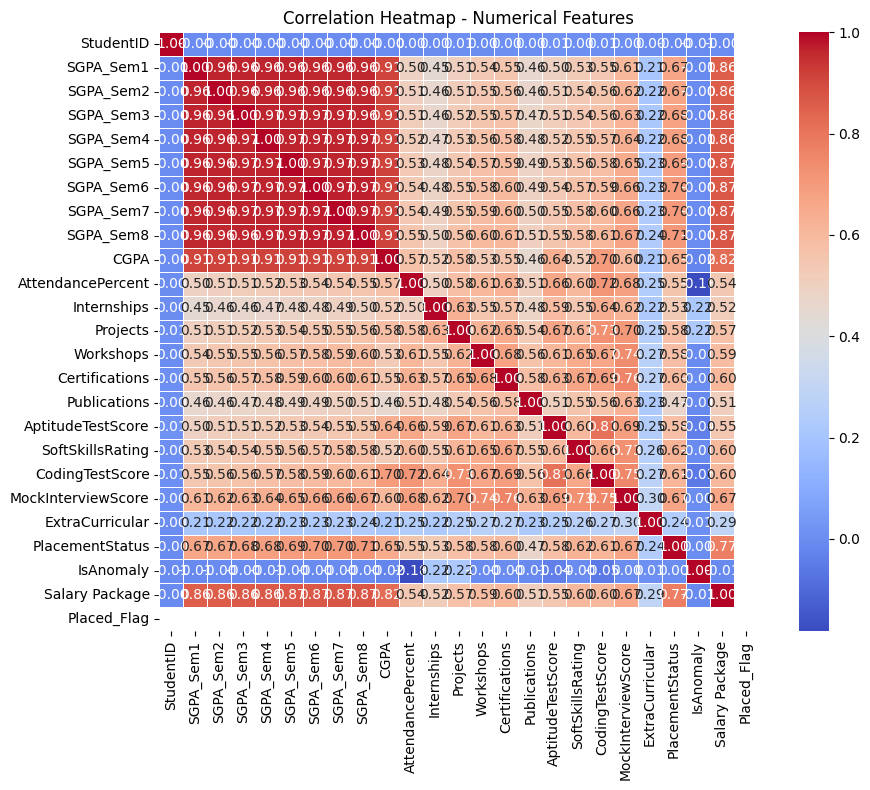

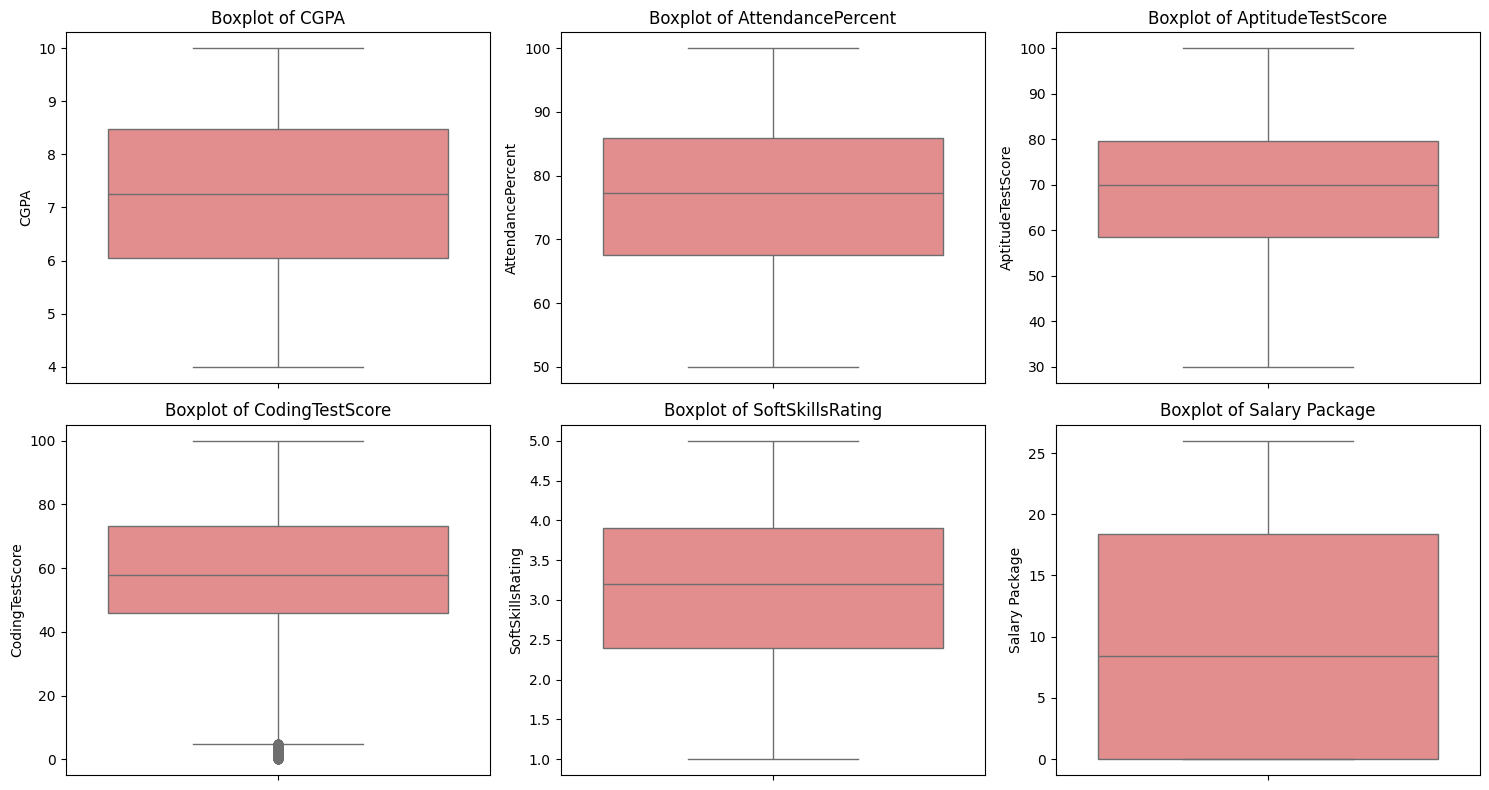


EDA_Report.pdf created successfully with 5 pages!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

# File name
# Make sure to upload 'placement_predict_50k Dataset (1) (1).csv' to your Colab environment.
CSV_PATH ="placement_predict_50k Dataset (1) (1).csv"
df = pd.read_csv(CSV_PATH)
# 1.Display first 5 rows
print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)
print("\nDATA TYPES")
print(df.dtypes)
print("\nDATASET INFORMATION")
df.info()
print("\nSTATISTICAL SUMMARY")
print(df.describe())
print("\nMISSING VALUES")
print(df.isnull().sum())
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())
print("\nPLACEMENT STATUS DISTRIBUTION")
print(df["PlacementStatus"].value_counts())
print("\nPLACEMENT STATUS PERCENTAGE")
print(df["PlacementStatus"].value_counts(normalize=True) * 100)
df['Placed_Flag'] = df['PlacementStatus'].apply(lambda x: 1 if x == 'Placed' else 0)
num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()
fig3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False) * 100
)

sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPlacement rate (%) by stream:")
print(placement_rate.round(2))
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()


fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()
pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms
pdf.savefig(fig3)   # Page 3: Placement Rate by Stream
pdf.savefig(fig4)   # Page 4: Correlation Heatmap
pdf.savefig(fig5)   # Page 5: Boxplots

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")

files.download('EDA_Report.pdf')